<a href="https://colab.research.google.com/github/SolJosefinaMercado/ProcesamientoDelHabla/blob/main/MERCADO_SOLJOSEFINA_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**Sol Josefina Mercado Jacobsen**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [117]:
# instalo dependencias necesarias para web scraping y visualización de datos
!pip install requests beautifulsoup4 wordcloud matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Extraccion 

In [ ]:

# importar librerias
import requests
from bs4 import BeautifulSoup

# creacion de la funcion para extraer el discurso de la pagina web

def extraer_discurso(url): 
    # headers evita bloqueos de seguridad la web al hacer scraping nos identifica 
    # como un navegador web
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa

    sopa = BeautifulSoup(response.content, "html.parser")

    # los paramentros de busqueda se ajustan a la estructura de la pagina web,
    # primero se busca un div con la clase 'views-field-body', si no se encuentra
    # se busca un article, si tampoco se encuentra se buscan todos los parrafos <p>
    # esta decision la tome en base a la estructura de la pagina web que contiene el discurso
    
    contenedor = sopa.find('div', class_ = 'views-field-body') or sopa.find('article')

    if contenedor:
        parrafos = contenedor.find_all('p')
    else:
        parrafos = sopa.find_all('p')

    # unimos todo el texto obtenido en un solo string, separando los párrafos con dos saltos de línea
    
    texto_discurso = "\n\n".join([p.get_text(strip=True) for p in parrafos if p.get_text(strip=True)])
    return texto_discurso

Extraccion desde url utilizando la funcion <extraer_discurso>, muestro los primeros 500 caracteres

In [119]:
# declaro la url donde esta alojado el discurso que quiero extraer
url_discurso = "https://www.casarosada.gob.ar/informacion/discursos/51360-cadena-nacional-del-presidente-javier-milei-sobre-la-causa-malvinas"

# Extraccion mediante funcion creada previamente
discurso = extraer_discurso(url_discurso)

# muestro los primeros 500 caracteres para verificar que se haya extraído correctamente
print(discurso[:500])

Cadena Nacional del Presidente Javier Milei sobre la Causa Malvinas

Argentinos, buenas noches. Hoy estoy aquí para informarles acerca de una serie de decisiones que hemos tomado respecto al ejercicio de nuestra soberanía sobre las Islas Malvinas, producto de meses de trabajo conjunto entre distintas áreas del Estado nacional.

En primer lugar, quiero ser claro con el mundo y expresar la posición del Estado argentino. Las Malvinas son argentinas, por historia y por derecho. No hay discusión al r


In [120]:
print(f"Longitud total del discurso: {len(discurso)} caracteres")

Longitud total del discurso: 12825 caracteres


Guardado del texto extraido como: "discurso_malvinas_TP1.txt"

In [121]:
nombre_archivo = "discurso_malvinas_TP1.txt"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(discurso)

print(f"Discurso guardado exitosamente en '{nombre_archivo}' listo para el análisis.")

OSError: [Errno 22] Invalid argument: 'discurso_malvinas_TP1.txt'

## 2- Preprocesamiento

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Para que una nube de palabras sea útil, es fundamental remover términos comunes que no aportan significado analítico (como "el", "la", "de", "que", "y"). Definiremos una lista personalizada de palabras vacías en español.

Antes de aplicar re.findall, el texto está almacenado en la variable texto_minuscula como una única cadena de texto continua (un string largo o bloque de texto completo) que contiene todas las oraciones juntas, con sus espacios, saltos de línea, puntos, comas y otros símbolos mezclados, tal como fue leído del archivo original.

Lo que hace la expresión regular es actuar como un filtro de búsqueda sobre ese bloque masivo: lo recorre de principio a fin y, cada vez que detecta un fragmento que cumple exactamente con las reglas del patrón (\b[a-záéíóúñü]+\b), lo "recorta" y lo almacena como un elemento independiente dentro de una lista de Python (palabras

In [ ]:
import re

stopwords_espaniol = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para", 
    "con", "no", "una", "su", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este", 
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me", 
    "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", 
    "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", 
    "antes", "algunos", "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", 
    "esa", "estos", "mucho", "quienes", "nada", "muchos", "cual", "sea", "poco", "ella", 
    "estar", "haber", "otras", "aunque", "ellas", "estuve", "estuviste", "estuvo",
    "ser", "son", "fue", "ha", "han", "hay", "hacer", "hizo", "estado", "está", "están",
    "será", "sido", "tiene", "tienen", "tener", "su", "sus", "les", "nos", "nosotros"
}

# limpiar el texto del discurso eliminando puntuación y convirtiendo a minúsculas usando regex 
texto_minuscula = discurso.lower()

# re.findall(patrón, texto)

palabras = re.findall(r'\b[a-záéíóúñü]+\b', texto_minuscula)

print(palabras[:20])  # Mostrar las primeras 20 palabras para verificar
print(f'Cantidad de palabras sin filtrado de Stopwords: {len(palabras)}')  # Mostrar el número total de palabras encontradas

['cadena', 'nacional', 'del', 'presidente', 'javier', 'milei', 'sobre', 'la', 'causa', 'malvinas', 'argentinos', 'buenas', 'noches', 'hoy', 'estoy', 'aquí', 'para', 'informarles', 'acerca', 'de']
Cantidad de palabras sin filtrado de Stopwords: 1975


In [ ]:
# filtrar stopwords del español y aquellas con menos de 3 caracteres
palabras_filtradas = [p for p in palabras if p not in stopwords_espaniol and len(p) > 2]

print(palabras_filtradas[:20])  # Mostrar las primeras 20 palabras filtradas para verificar
print(f"Palabras listas para la nube tras el filtrado de Stopwords: {len(palabras_filtradas)}")

['cadena', 'nacional', 'presidente', 'javier', 'milei', 'causa', 'malvinas', 'argentinos', 'buenas', 'noches', 'hoy', 'estoy', 'aquí', 'informarles', 'acerca', 'serie', 'decisiones', 'hemos', 'tomado', 'respecto']
Palabras listas para la nube tras el filtrado de Stopwords: 1063


In [ ]:
# unir las palaras filtradas en un solo string para generar la nube de palabras
texto_filtrado = " ".join(palabras_filtradas)

print(texto_filtrado[:100])  


cadena nacional presidente javier milei causa malvinas argentinos buenas noches hoy estoy aquí infor


In [ ]:
# guardado para el analisis posterior 

nombre_archivo = "discurso_malvinas_TP1_Filtrado.txt"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(texto_filtrado)

print(f"Discurso guardado exitosamente en '{nombre_archivo}' listo para el análisis.")

Discurso guardado exitosamente en 'discurso_malvinas_TP1_Filtrado.txt' listo para el análisis.


# Generacion y visualizacion de la nube de palabras
Usando WordCloud y matplotlib

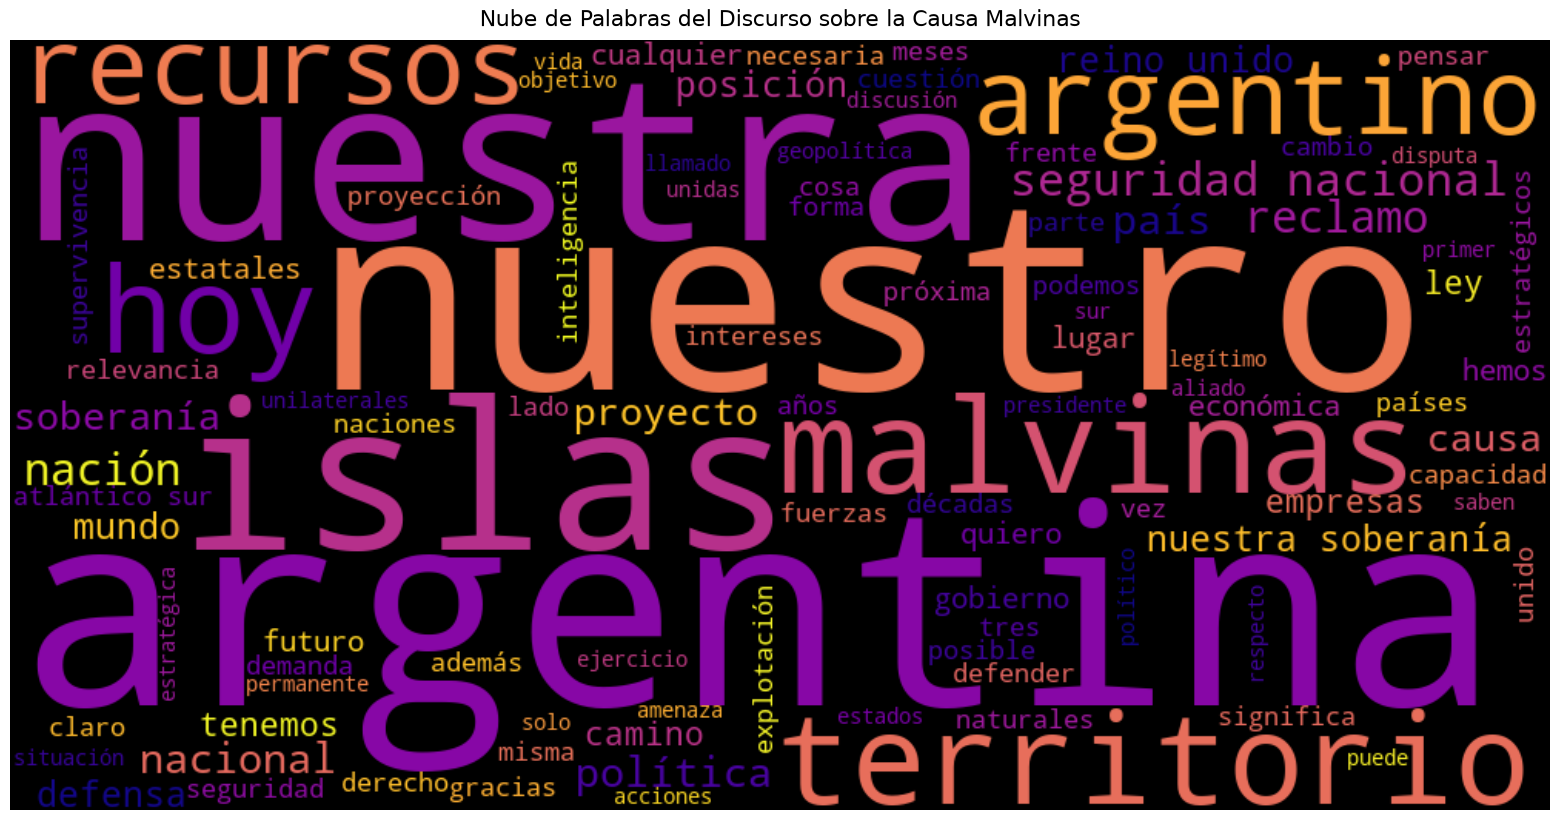

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# parametros de la nube de palabras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black',
    colormap='plasma',
    max_words=100,
    contour_width=3,
    contour_color='steelblue',
).generate(texto_filtrado)

# mostrar en el notebook la nube de palabras
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # ocultar los ejes
plt.title("Nube de Palabras del Discurso sobre la Causa Malvinas", fontsize=16, pad= 10)
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


El orden lógico y correcto para este tipo de pipelines de Procesamiento del Lenguaje Natural (PLN) es el siguiente:

Limpieza gruesa de scraping: Sacar etiquetas HTML, código basura, scripts o URLs que no aportan.

Descomposición en oraciones: Separar el texto en oraciones usando el texto con su puntuación intacta.

Preprocesamiento por oración: A cada oración individual se le aplica la limpieza fina (pasar a minúsculas, quitar números, símbolos extraños, etc.).

Eliminación de stopwords y Vectorización: En este último paso (que herramientas como CountVectorizer hacen de forma automática si se lo configurás), se descartan las stopwords y se arma la matriz documento-vocabulario

El orden lógico y profesional de un pipeline de texto es el siguiente:

Limpieza de ruido (URLs, HTML, saltos de línea).

Segmentación en oraciones.

Tokenización en palabras.

Lematización o Stemming (agrupar variantes de una misma palabra).

Eliminación de stopwords.

Vectorización (TF-IDF o CountVectorizer).

In [ ]:
# importacion de las librerias necesarias
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# para descomponer en oraciones debo usar el texto crudo, ya que el texto filtrado no tiene puntuación y no se puede separar en oraciones
texto_crudo = discurso.lower()

# reemplazo los saltos de línea por espacios para que el texto sea continuo
# y posteriormente pueda ser tokenizado en oraciones y palabras (caso 'malvinas/n/nargentinos')
texto_sin_saltos = texto_crudo.replace('\n', ' ').replace('\r', ' ')

print(texto_sin_saltos[:100]) 

cadena nacional del presidente javier milei sobre la causa malvinas  argentinos, buenas noches. hoy 


## Descomposicion de oraciones

In [ ]:
oraciones = sent_tokenize(texto_sin_saltos, language='spanish')
print(f'oraciones encontradas: {len(oraciones)}')

oraciones encontradas: 94


In [ ]:
# oraciones equivale a documentos del apunte 
oraciones 

['cadena nacional del presidente javier milei sobre la causa malvinas  argentinos, buenas noches.',
 'hoy estoy aquí para informarles acerca de una serie de decisiones que hemos tomado respecto al ejercicio de nuestra soberanía sobre las islas malvinas, producto de meses de trabajo conjunto entre distintas áreas del estado nacional.',
 'en primer lugar, quiero ser claro con el mundo y expresar la posición del estado argentino.',
 'las malvinas son argentinas, por historia y por derecho.',
 'no hay discusión al respecto.',
 'las islas formaron parte del territorio argentino desde los orígenes de nuestra nación.',
 'en 1833 el reino unido ocupó las malvinas, expulsó a las autoridades argentinas e instaló una situación colonial que se perpetúa hasta nuestros días.',
 'esto implica que los isleños, al ser una población implantada en un territorio usurpado, no tienen un derecho legítimo a la autodeterminación y que cualquier argumento basado en referendos realizado en las islas es inválido.

## Tokenizacion en palabras

In [93]:
import numpy as np

# palabras es una lista de listas, donde cada sublista contiene las palabras de una oración
# cada palabra será un token, y cada oración será un documento en el corpus

palabras = np.char.split(oraciones, sep=' ')
print(palabras)

[list(['cadena', 'nacional', 'del', 'presidente', 'javier', 'milei', 'sobre', 'la', 'causa', 'malvinas', '', 'argentinos,', 'buenas', 'noches.'])
 list(['hoy', 'estoy', 'aquí', 'para', 'informarles', 'acerca', 'de', 'una', 'serie', 'de', 'decisiones', 'que', 'hemos', 'tomado', 'respecto', 'al', 'ejercicio', 'de', 'nuestra', 'soberanía', 'sobre', 'las', 'islas', 'malvinas,', 'producto', 'de', 'meses', 'de', 'trabajo', 'conjunto', 'entre', 'distintas', 'áreas', 'del', 'estado', 'nacional.'])
 list(['en', 'primer', 'lugar,', 'quiero', 'ser', 'claro', 'con', 'el', 'mundo', 'y', 'expresar', 'la', 'posición', 'del', 'estado', 'argentino.'])
 list(['las', 'malvinas', 'son', 'argentinas,', 'por', 'historia', 'y', 'por', 'derecho.'])
 list(['no', 'hay', 'discusión', 'al', 'respecto.'])
 list(['las', 'islas', 'formaron', 'parte', 'del', 'territorio', 'argentino', 'desde', 'los', 'orígenes', 'de', 'nuestra', 'nación.'])
 list(['en', '1833', 'el', 'reino', 'unido', 'ocupó', 'las', 'malvinas,', 'ex

In [ ]:
# recorro la lista de listas y creo una lista plana con todas las palabras (tokens)

tokens = [word for sublist in palabras for word in sublist]

print(tokens)

['cadena', 'nacional', 'del', 'presidente', 'javier', 'milei', 'sobre', 'la', 'causa', 'malvinas', '', 'argentinos,', 'buenas', 'noches.', 'hoy', 'estoy', 'aquí', 'para', 'informarles', 'acerca', 'de', 'una', 'serie', 'de', 'decisiones', 'que', 'hemos', 'tomado', 'respecto', 'al', 'ejercicio', 'de', 'nuestra', 'soberanía', 'sobre', 'las', 'islas', 'malvinas,', 'producto', 'de', 'meses', 'de', 'trabajo', 'conjunto', 'entre', 'distintas', 'áreas', 'del', 'estado', 'nacional.', 'en', 'primer', 'lugar,', 'quiero', 'ser', 'claro', 'con', 'el', 'mundo', 'y', 'expresar', 'la', 'posición', 'del', 'estado', 'argentino.', 'las', 'malvinas', 'son', 'argentinas,', 'por', 'historia', 'y', 'por', 'derecho.', 'no', 'hay', 'discusión', 'al', 'respecto.', 'las', 'islas', 'formaron', 'parte', 'del', 'territorio', 'argentino', 'desde', 'los', 'orígenes', 'de', 'nuestra', 'nación.', 'en', '1833', 'el', 'reino', 'unido', 'ocupó', 'las', 'malvinas,', 'expulsó', 'a', 'las', 'autoridades', 'argentinas', 'e', 

## Lematizacion:
Por que? porque respeta el diccionario y la gramatica (utiliza diccionario y reglas morfologicas del español para devolver el lema o palabra base) y este es un texto cargado de conceptos 

* Sin lemantizar la matriz final queda con terminos similares como ultimo / ultimos que en esencia son la misma palabra en singular y plural, lo que no añade nada al analisis

In [96]:
# 1. Instalar la librería spaCy
!pip install spacy

# 2. Descargar el modelo de idioma español
!python -m spacy download es_core_news_sm

   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ------------- -------------------------- 5.2/15.2 MB 31.6 MB/s eta 0:00:01
   ----------------------------------- ---- 13.4/15.2 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 15.2/15.2 MB 33.7 MB/s  0:00:00
   ---------------------------------------- 0.0/656.5 kB ? eta -:--:--
   ---------------------------------------- 656.5/656.5 kB 25.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 34.3 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 38.1 MB/s  0:00:00
   ---------------------------------------- 0.0/818.2 kB ? eta -:--:--
   ---------------------------------------- 818.2/818.2 kB 25.4 MB/s  0:00:00

   ------- --------------------------------  3/17 [spacy-legacy]
   --------- ------------------------------  4/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ------------- -------------------------- 4.5/12.9 MB 31.9 MB/s eta 0:00:01
     --------------------------------------  12.8/12.9 MB 37.9 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 35.5 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
import spacy

# Cargar el modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")

lista_de_oraciones = oraciones

oraciones_lematizadas = []

for oracion in lista_de_oraciones:
    doc = nlp(oracion)
    # # Filtramos: que no sea stopword, que no sea puntuación, que no sea espacio en blanco 
    # y que tenga más de 2 caracteres
    tokens_lema = [
        token.lemma_ for token in doc 
        if not token.is_stop and not token.is_punct and not token.is_space and len(token.text) > 2
    ]
    oraciones_lematizadas.append(" ".join(tokens_lema))

print(oraciones_lematizadas[:5])  # Mostrar las primeras 5 oraciones lematizadas para verificar

['cadena nacional presidente javier milei causa malvina argentino noche', 'informar él acerca serie decisión tomar ejercicio soberanía isla malvina producto mes trabajo conjunto distinto área nacional', 'lugar querer mundo expresar posición argentino', 'malvina argentino historia derecho', 'discusión']


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soljo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True


#### 2.3.2 Determina la longitud de tu vocabulario.

In [105]:
# Si la misma palabra aparece 5 veces en tu lista, set() la cuenta una sola vez, 
# dándote el tamaño real del vocabulario de tu corpus.

# vocabulario = set(tokens_filtrados)

vocabulario = set(oraciones_lematizadas)
print(f'Tamaño del vocabulario (palabras unicas): {len(vocabulario)}')

Tamaño del vocabulario (palabras unicas): 94



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [107]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# 1. Configuramos el vectorizador TF-IDF
# - stop_words: elimina las palabras vacías en español
# - token_pattern: toma solo palabras de 3 o más letras (evita símbolos sueltos y corta la basura)
tfidf_vectorizer = TfidfVectorizer()

# 2. Aplicamos fit_transform sobre tu lista de oraciones (cada oración es un documento)
matriz_tfidf = tfidf_vectorizer.fit_transform(oraciones_lematizadas)

# 3. Longitud del vocabulario resultante
print(f"Longitud del vocabulario: {len(tfidf_vectorizer.get_feature_names_out())}")
print("Vocabulario:", tfidf_vectorizer.get_feature_names_out())



Longitud del vocabulario: 510
Vocabulario: ['180' '1833' '26659' 'abandonar' 'accionista' 'acción' 'acechar'
 'acelerar' 'acerca' 'acompañir' 'acostumbrar' 'actividad' 'actor'
 'actuar' 'adicional' 'adopción' 'aeroespacial' 'afectado' 'afectar'
 'afín' 'aliado' 'alimentar' 'alimento' 'alineado' 'amenaza' 'amenazar'
 'amigo' 'ampliar' 'antártida' 'antártido' 'aplicación' 'apoyo' 'apropiar'
 'argentina' 'argentino' 'argumento' 'arma' 'armadas' 'arrebatar'
 'articular' 'artificial' 'asegurar' 'atlántico' 'atraer' 'ausencia'
 'autodeterminación' 'autoridad' 'autorización' 'autorizado' 'avance'
 'avanzar' 'año' 'basado' 'base' 'bendigar' 'bilateral' 'brazo'
 'británico' 'cadena' 'cambiar' 'cambiario' 'cambio' 'camino'
 'cancillería' 'capacidad' 'capaz' 'capricho' 'carácter' 'causa'
 'celeridad' 'central' 'cepo' 'cerca' 'cero' 'cielo' 'claro' 'cláusula'
 'colaborar' 'colocar' 'colonial' 'compañía' 'competencia' 'competir'
 'condición' 'conducir' 'confiable' 'confiar' 'conforme' 'congreso'
 '

In [113]:
import pandas as pd

# 1. Convertimos la matriz dispersa (sparse matrix) a un array de numpy y armamos el DataFrame
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)

# 2. Opcional: Para ver mejor las filas, podés ponerle de índice las oraciones originales
df_tfidf.index = [f"Oración {i+1}" for i in range(len(oraciones_lematizadas))]

# Mostramos el DataFrame completo (o usa print(df_tfidf.head()) si es muy grande)
df_tfidf

,180,1833,26659,abandonar,accionista,acción,acechar,acelerar,acerca,acompañir,...,violación,violencia,violentir,vivir,volver,voz,vulnerar,yacer,área,él
Oración 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.275657,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.275657,0.197038
Oración 3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Oración 90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.604659,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.707107,0.0,0.0,0.0,0.0,0.000000,0.000000


## Cuales son las palabras mas importantes de todo el texto ? 

In [114]:
# Sumamos los valores de TF-IDF por columna y los ordenamos de mayor a menor
palabras_importantes = df_tfidf.sum().sort_values(ascending=False)

print("Top 10 palabras más importantes del texto:")
print(palabras_importantes.head(10))

Top 10 palabras más importantes del texto:
argentina    3.704304
malvina      3.495823
argentino    3.299580
nacional     3.251492
camino       3.010223
isla         2.997992
reclamo      2.773779
seguridad    2.719284
soberanía    2.663636
nación       2.562152
dtype: float64


## De que habla cada oracion en particular ? 

In [115]:
# Para cada oración, encontramos la columna con el valor máximo
for idx, row in df_tfidf.iterrows():
    palabra_clave = row.idxmax()
    peso = row.max()
    if peso > 0:  # Si la oración tiene palabras con peso
        print(f"[{idx}] Palabra más representativa: '{palabra_clave}' (Peso: {peso:.3f})")

[Oración 1] Palabra más representativa: 'cadena' (Peso: 0.400)
[Oración 2] Palabra más representativa: 'acerca' (Peso: 0.276)
[Oración 3] Palabra más representativa: 'expresar' (Peso: 0.513)
[Oración 4] Palabra más representativa: 'historia' (Peso: 0.640)
[Oración 5] Palabra más representativa: 'discusión' (Peso: 1.000)
[Oración 6] Palabra más representativa: 'formar' (Peso: 0.535)
[Oración 7] Palabra más representativa: '1833' (Peso: 0.323)
[Oración 8] Palabra más representativa: 'argumento' (Peso: 0.286)
[Oración 9] Palabra más representativa: 'sostener' (Peso: 0.581)
[Oración 10] Palabra más representativa: 'sur' (Peso: 0.402)
[Oración 11] Palabra más representativa: 'territorio' (Peso: 0.301)
[Oración 12] Palabra más representativa: 'bilateral' (Peso: 0.284)
[Oración 13] Palabra más representativa: 'causa' (Peso: 0.596)
[Oración 14] Palabra más representativa: 'geopolítico' (Peso: 0.409)
[Oración 15] Palabra más representativa: 'apoyo' (Peso: 0.270)
[Oración 16] Palabra más represe

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.